# Causal Lab: ATE Recovery Under Controlled DGP and Observable Confounders

This notebook evaluates five causal estimators on their ability to recover a
known average treatment effect (ATE) from synthetic data. All data is generated
from controlled DGPs where the true ATE is fixed at $2.0$ and all relevant
covariates are observed by construction. The question is not whether we have the
right variables — we do — but whether standard methods can exploit them correctly
under different structural conditions.

This is the selection-on-observables setting. There are no unobserved confounders,
no instruments, no panel structure. Just $X$, $T$, and $Y$, and the challenge of
recovering the causal effect of $T$ on $Y$ when the assignment mechanism and
outcome surface take different forms. Even in this idealised setting, naive methods
fail. The scenarios below show how and why.

---

## Scenarios

We examine three DGP scenarios, each isolating a distinct source of estimator
stress:

1. **Propensity Score Overlap** — treatment assignment becomes increasingly
   deterministic as a function of covariates, degrading the common support region
   required for credible comparisons between treated and untreated units.

2. **Nonlinearity** — TBC

3. **Covariate Dimensionality** — TBC

Each scenario introduces a single knob that modulates intensity from mild to
severe, holding everything else fixed. This allows estimator failures to be
attributed cleanly to the structural feature under study.

---

## Estimator Suite

All estimators are implemented in `src/ate_suite.py` and share the interface
`fn(Y, T, X) -> float`. 

- **Ordinary Least Squares (OLS)** regresses $Y$ on $T$ and $X$ using `statsmodels.OLS` and reads off
  the coefficient on $T$. It is the natural econometric baseline: include all
  controls in a linear model and assume the functional form is correct. It uses
  no propensity score and assumes the confounding relationship is additive and
  linear.

- **Inverse Probability Weighting (IPW)** estimates propensity scores using `sklearn.LogisticRegression` and
  constructs Horvitz-Thompson weights. Each unit's outcome is upweighted by the
  inverse of its treatment probability, rebalancing the sample so treated and
  control groups look comparable on average. It uses no outcome model. Propensity
  scores are clipped to $[0.05, 0.95]$ to prevent weight explosion near the
  boundary.

- **Flexible Regression Outcome (RO)** is a T-learner built on two `sklearn.RandomForestRegressor`
  models, one trained on treated units and one on controls. Predicted potential
  outcomes are generated for every unit under both treatment values and the ATE
  is their average difference. It allows a flexible, nonparametric outcome surface
  but applies no correction for selection into treatment.

- **Augmented IPW (AIPW)** is implemented via `econml.dr.LinearDRLearner` with a
  `LogisticRegression` propensity model and `LassoCV` outcome model. It augments
  the IPW estimator with an outcome model correction, making it doubly robust:
  consistent if either the propensity or outcome model is correctly specified.
  Cross-fitting across five folds is handled internally by `econml`.

- **Double Machine Learning (DML)** is implemented via `econml.dml.LinearDML` with `LassoCV` for both
  outcome and treatment nuisance models. Rather than reweighting by propensity
  scores, it partials out the effect of $X$ from both $Y$ and $T$ separately
  using cross-fitted regressions, then estimates the treatment effect on the
  residuals. This avoids direct propensity weighting and is designed to handle
  high-dimensional and nonlinear nuisance functions.

Specifications are fixed across all scenarios so that
any differences in performance are attributable to the estimator, not tuning
choices.

---

## Key Findings

- **Scenario 1: Propensity Score Overlap**  — 
When overlap is healthy all five estimators recover the true ATE reasonably well.
As overlap degrades, estimators fail in distinct and revealing ways. Flexible RO
accumulates the largest bias: without any selection correction, its outcome models
extrapolate across covariate regions they were never trained on. IPW fails through
weight explosion: as propensity scores polarise, a shrinking set of boundary units
dominates the estimate, producing both bias and variance. AIPW preserves near-zero
bias throughout but variance inflates sharply at high $\gamma$, making it
unreliable on any single dataset even when correct on average. OLS and DML are the
most resilient — OLS because the primary confounder enters linearly and is directly
controlled, DML because it avoids propensity weighting entirely through residualisation.

- **Scenario 2:** TBC

- **Scenario 3:** TBC


In [1]:
import numpy as np

TRUE_ATE = 2.0
SEED=89

## Scenario 1: Propensity Score Overlap

A core assumption in the selection-on-observables framework is that every unit
has a non-zero probability of receiving either treatment value, given its
covariates. This is the overlap assumption, sometimes called positivity. When it
holds, treated and untreated units with similar covariate profiles can be
meaningfully compared. When it fails, estimators are forced to extrapolate across
regions of covariate space where one group is absent, and any estimate of the
treatment effect becomes unreliable regardless of how sophisticated the method is.

We degrade overlap via a single parameter $\gamma$ that scales the log-odds of
treatment assignment. At low $\gamma$ treatment is close to random. As $\gamma$
increases assignment becomes increasingly deterministic, pushing propensity scores
toward 0 and 1 and shrinking the region of common support.

The sections below set out the DGP, the distribution of propensity scores across
$\gamma$ values, and estimator performance in terms of bias and RMSE.

### 1a - Data Generating Process

Covariates $X \in \mathbb{R}^{10}$ are drawn independently from a standard normal
distribution. Treatment assignment and the outcome are driven by partially
overlapping subsets of covariates. $X_0$ is the only true confounder, entering
both models. $X_4$ and $X_5$ affect treatment probability only. $X_1$, $X_2$,
and $X_3$ affect the outcome only. The remaining covariates are inactive noise.

The propensity score is a logistic function of a linear combination of $X_0$,
$X_4$, and $X_5$, scaled by $\gamma$:

$$ps_i = \sigma\bigl(\gamma \cdot (X_{i0} + 0.3\, X_{i4} - 0.2\, X_{i5})\bigr), \qquad T_i \sim \text{Bernoulli}(ps_i)$$

Since $X_0$, $X_4$, and $X_5$ are standard normal, the linear combination inside
the sigmoid has mean zero and unit-scale variation. At $\gamma=1$ this produces
propensity scores spread across $(0, 1)$ with meaningful overlap. As $\gamma$
increases the sigmoid is applied to increasingly large values, pushing scores
toward 0 and 1 and concentrating each group in opposite tails of covariate space.
$\gamma$ is therefore a direct dial on how deterministic treatment assignment is.

The outcome is a nonlinear function of treatment and covariates:

$$Y_i = 2.0 \cdot T_i + 3X_{i0} + 2X_{i1}^2 + 1.5\, X_{i0} X_{i2} + 2\sin(X_{i3}) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1)$$

$X_0$ enters the outcome linearly and through an interaction with $X_2$, making
it a strong confounder. The nonlinear terms in $X_1$ and $X_3$ add outcome
complexity that linear estimators will partially misspecify. The outcome structure
is held fixed across all $\gamma$ values so that any change in estimator
performance is driven solely by overlap degradation.

In [2]:
from scipy.special import expit

def make_overlap_dgp(n=1000, gamma=1.0, true_ate=TRUE_ATE, seed=SEED):
    """
    DGP for the propensity overlap scenario.

    Parameters
    ----------
    n       : sample size
    gamma   : overlap divergence. Higher values concentrate propensity
              scores toward 0 and 1, reducing common support.
    true_ate: ground truth average treatment effect
    seed    : random seed for reproducibility

    Returns
    -------
    Y : array (n,)   observed outcomes
    T : array (n,)   binary treatment indicator
    X : array (n, 10) pre-treatment covariates, each column iid N(0,1)
    ps: array (n,)   true propensity scores
    """
    rng = np.random.default_rng(seed)

    # ten standard normal covariates
    X = rng.standard_normal((n, 10))

    # treatment probability driven by X0 (shared confounder), X4 and X5 (treatment only)
    # gamma scales the log-odds: higher gamma -> more extreme probabilities
    ps = expit(gamma * (X[:, 0] + 0.3 * X[:, 4] - 0.2 * X[:, 5]))

    # treatment drawn as independent Bernoulli trials
    T = rng.binomial(1, ps)

    # outcome driven by X0 (shared confounder), X1, X2, X3 (outcome only)
    # X0 is the only true confounder — it appears in both models
    Y = (true_ate * T
         + 3 * X[:, 0]                  # shared confounder, linear
         + 2 * X[:, 1]**2               # outcome only, nonlinear
         + 1.5 * X[:, 0] * X[:, 2]      # outcome only, interaction with confounder
         + 2 * np.sin(X[:, 3])           # outcome only, smooth nonlinearity
         + rng.standard_normal(n))

    return Y, T.astype(float), X, ps

We consider eight values of $\gamma \in \{0.1, 0.25, 0.5, 0.75, 1, 1.5, 2.5, 5\}$
to examine how overlap degrades across the full spectrum from near-random to
near-deterministic assignment. The plots below show the true propensity score
distributions for treated and control units at each value, along with group means.

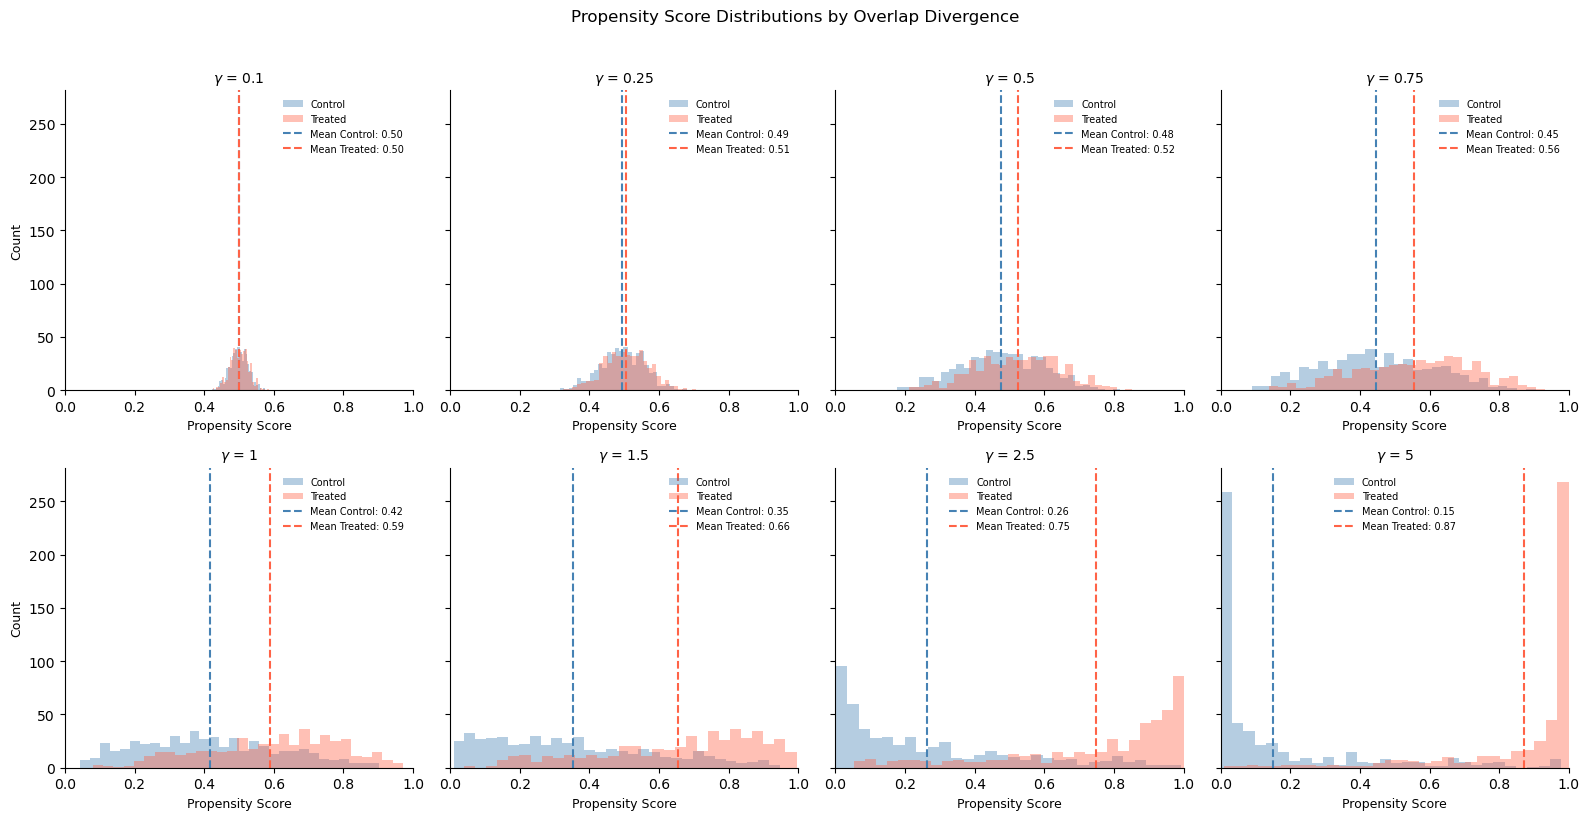

In [14]:
import matplotlib.pyplot as plt

N      = 1000
GAMMAS = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2.5, 5]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()

for ax, gamma in zip(axes, GAMMAS):
    Y, T, X, ps = make_overlap_dgp(gamma=gamma)

    mean_ctrl    = ps[T == 0].mean()
    mean_treated = ps[T == 1].mean()

    ax.hist(ps[T == 0], bins=30, alpha=0.4, label="Control",
            color="steelblue", edgecolor="none")
    ax.hist(ps[T == 1], bins=30, alpha=0.4, label="Treated",
            color="tomato", edgecolor="none")
    ax.axvline(mean_ctrl, color="steelblue", linewidth=1.5, linestyle="--",
               label=f"Mean Control: {mean_ctrl:.2f}")
    ax.axvline(mean_treated, color="tomato", linewidth=1.5, linestyle="--",
               label=f"Mean Treated: {mean_treated:.2f}")
    ax.set_title(f"$\\gamma$ = {gamma}", fontsize=10)
    ax.set_xlabel("Propensity Score", fontsize=9)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Count", fontsize=9)
axes[4].set_ylabel("Count", fontsize=9)

fig.suptitle("Propensity Score Distributions by Overlap Divergence", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_propensity_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

At $\gamma=0.1$ both groups are essentially indistinguishable — mean propensity
scores of $0.50$ for control and $0.50$ for treated, with distributions tightly
overlapping near $0.5$. By $\gamma=1$ the means have separated to $0.42$ and
$0.59$. At $\gamma=2.5$ they stand at $0.26$ and $0.75$, and by $\gamma=5$ the
groups have almost entirely retreated to opposite ends of the score distribution
at $0.15$ and $0.87$. The common support region — where both groups have
meaningful representation — has effectively collapsed.

### 1b - Simulation & Results

With the DGP in place we run all five estimators across each of the eight
$\gamma$ values. For each combination we generate $N=50$ independent datasets
by varying the random seed, run every estimator on each dataset, and aggregate
results. Repeated draws are insightful because any single dataset is subject to
sampling noise — averaging across 50 realisations gives stable estimates of each
estimator's expected bias and RMSE at a given level of overlap degradation.

Results are summarised in per-gamma tables below, followed by bias and RMSE
curves across the full $\gamma$ spectrum.

In [4]:
import sys
import warnings
warnings.filterwarnings("ignore")
sys.path.append("src")

import pandas as pd
from joblib import Parallel, delayed
from tqdm import tqdm
from ate_suite import ESTIMATORS

N_SIMS = 50

def run_sim(sim):
    rows = []
    for gamma in GAMMAS:
        Y, T, X, ps = make_overlap_dgp(gamma=gamma, seed=sim)
        for name, fn in ESTIMATORS.items():
            est = fn(Y, T, X)
            rows.append({
                "gamma"    : gamma,
                "estimator": name,
                "sim"      : sim,
                "estimate" : est,
            })
    return rows

results = Parallel(n_jobs=-1)(
    delayed(run_sim)(sim) for sim in tqdm(range(N_SIMS), desc="Simulations")
)

records = [row for batch in results for row in batch]

df = pd.DataFrame(records)
df["bias"]     = df["estimate"] - TRUE_ATE
df["sq_error"] = df["bias"] ** 2

Simulations: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]


The simulation loop runs all five estimators across each value of $\gamma$ over $N=50$ draws, averaging results to produce stable bias and RMSE estimates. Results are reported as per-gamma summary tables followed by a visual comparison across the full overlap degradation spectrum.

In [5]:
summary = (
    df.groupby(["gamma", "estimator"])
    .agg(
        ATE      =("estimate", "mean"),
        Bias     =("bias",     "mean"),
        Variance =("estimate", "var"),
        RMSE     =("sq_error", lambda x: x.mean() ** 0.5),
    )
    .round(3)
    .reset_index()
)

for gamma in GAMMAS:
    subset = summary[summary["gamma"] == gamma].drop(columns="gamma")
    subset = subset.set_index("estimator")
    print(f"\nγ = {gamma}")
    display(subset)


γ = 0.1


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.980,-0.020,0.054,0.230
DML,2.000,-0.000,0.047,0.215
Flexible RO,2.018,0.018,0.011,0.105
IPW,1.990,-0.010,0.047,0.215
OLS,1.988,-0.012,0.046,0.214



γ = 0.25


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.002,0.002,0.051,0.223
DML,2.002,0.002,0.048,0.217
Flexible RO,2.043,0.043,0.012,0.118
IPW,1.991,-0.009,0.047,0.214
OLS,1.988,-0.012,0.045,0.211



γ = 0.5


...

,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.052,0.052,0.267,0.514
DML,1.964,-0.036,0.068,0.261
Flexible RO,2.459,0.459,0.038,0.498
IPW,2.220,0.220,0.156,0.449
OLS,1.967,-0.033,0.064,0.252



γ = 2.5


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.043,0.043,0.469,0.680
DML,1.944,-0.056,0.070,0.268
Flexible RO,2.833,0.833,0.044,0.859
IPW,2.719,0.719,0.095,0.781
OLS,1.949,-0.051,0.062,0.251



γ = 5


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.916,-0.084,0.362,0.602
DML,1.984,-0.016,0.085,0.290
Flexible RO,3.548,1.548,0.044,1.562
IPW,3.419,1.419,0.072,1.444
OLS,1.991,-0.009,0.078,0.276


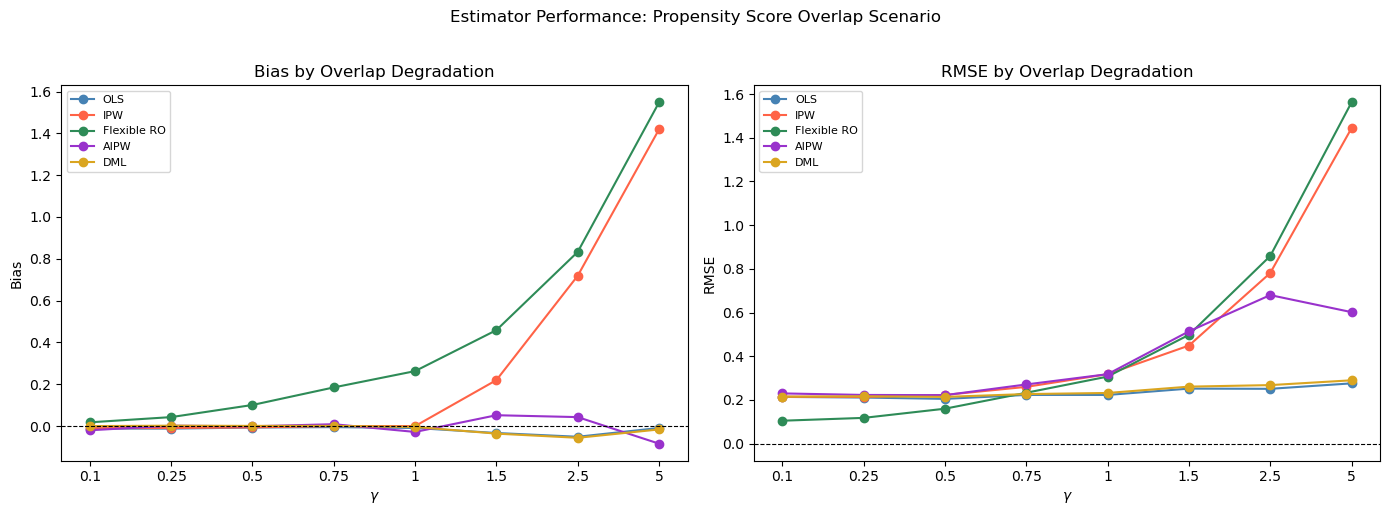

In [6]:
import matplotlib.pyplot as plt

estimator_order = ["OLS", "IPW", "Flexible RO", "AIPW", "DML"]
colors = ["steelblue", "tomato", "seagreen", "darkorchid", "goldenrod"]
color_map = dict(zip(estimator_order, colors))

x_pos    = list(range(len(GAMMAS)))
x_labels = [str(g) for g in GAMMAS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, ylabel in [("Bias", axes[0], "Bias"), ("RMSE", axes[1], "RMSE")]:
    for name in estimator_order:
        subset = summary[summary["estimator"] == name].sort_values("gamma")
        vals   = subset["RMSE"].values if metric == "RMSE" else subset["Bias"].values
        ax.plot(x_pos, vals, marker="o", label=name, color=color_map[name])

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Overlap Degradation")
    ax.legend(fontsize=8)

plt.suptitle("Estimator Performance: Propensity Score Overlap Scenario", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_bias_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

The bias chart reveals a clear separation between estimators as overlap degrades.
At low $\gamma$ all five estimators recover the true ATE reasonably well. Beyond
$\gamma=1$ the picture diverges sharply.

- **Flexible RO** accumulates the largest bias. As $\gamma$ increases, treated
  and control units occupy increasingly separate covariate regions. Each forest
  is then forced to predict potential outcomes for units it has never seen, and
  random forests extrapolate poorly — defaulting toward their training leaf means
  rather than the true counterfactual. The ATE estimate drifts further from 2.0
  with every step up in $\gamma$.

- **IPW** fails for a different reason. As propensity scores polarise toward 0
  and 1, inverse weights explode. Even with clipping, the effective sample
  collapses to a thin set of boundary units that carry disproportionate influence.
  The ATE is no longer an average over the full population but over a small,
  unrepresentative slice of it.

- **OLS** holds up because it never touches propensity scores. It controls for
  $X_0$ directly as a covariate, which absorbs most of the confounding signal
  regardless of how separated the groups become. Outcome model misspecification
  introduces modest bias but overlap degradation alone does not break it.

- **DML** avoids propensity weighting entirely by partialling out treatment and
  outcome on $X$ before estimating the effect. The residualised problem is much
  less sensitive to distributional separation between groups, which is why bias
  stays near zero and RMSE remains tight across the full $\gamma$ range.

- **AIPW** keeps bias controlled but variance grows at high $\gamma$. The outcome
  model does the heavy lifting on confounding, but the IPW correction term
  amplifies noise as weights become extreme. The widening gap between

### 1c. Further Diagnostics

The bias and RMSE curves tell us *that* estimators fail but not always *why*.
Two further diagnostics ground the failures mechanically. 

We focus on IPW and
AIPW: the two estimators that explicitly construct and invert propensity scores
as part of their estimation procedure. DML also models the treatment as a function
of $X$ but never converts those predictions into inverse weights, insulating it
from the instability examined here.


### 1c(i) - IPW Weight Instability

We estimate propensity scores using the same logistic regression specification as
the IPW estimator and compute inverse probability weights for each unit. For
treated units the weight is $1/\hat{ps}_i$ and for control units $1/(1-\hat{ps}_i)$.
Weights are clipped to $[0.05, 0.95]$ consistent with the estimator. The
histograms below show the full weight distribution across all units at each
$\gamma$ value. A tight distribution near $2.0$ indicates balanced groups and
stable reweighting. A heavy right tail indicates a small number of units carrying
disproportionate influence over the final estimate.

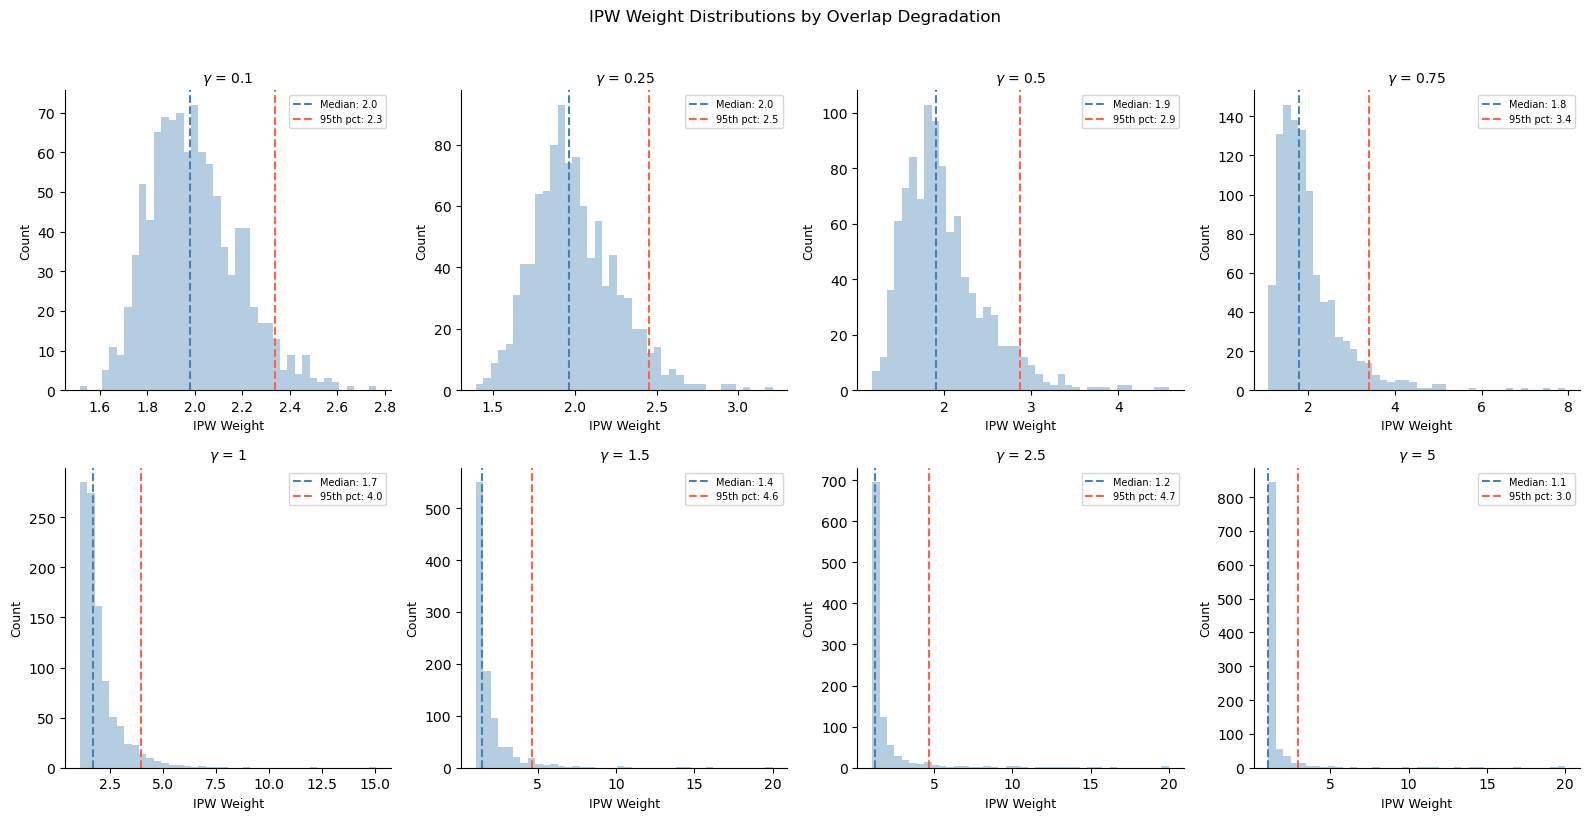

In [9]:
from sklearn.linear_model import LogisticRegression
from ate_suite import PS_CLIP, SEED

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for ax, gamma in zip(axes, GAMMAS):
    Y, T, X, ps = make_overlap_dgp(gamma=gamma)
    ps_hat = (
        LogisticRegression(random_state=SEED)
        .fit(X, T)
        .predict_proba(X)[:, 1]
    )
    ps_hat  = np.clip(ps_hat, *PS_CLIP)
    weights = T / ps_hat + (1 - T) / (1 - ps_hat)

    ax.hist(weights, bins=40, color="steelblue", alpha=0.4, edgecolor="none")
    ax.axvline(np.median(weights), color="steelblue", linewidth=1.5,
               linestyle="--", label=f"Median: {np.median(weights):.1f}")
    ax.axvline(np.percentile(weights, 95), color="tomato", linewidth=1.5,
               linestyle="--", label=f"95th pct: {np.percentile(weights, 95):.1f}")
    ax.set_title(f"$\\gamma$ = {gamma}", fontsize=10)
    ax.set_xlabel("IPW Weight", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("IPW Weight Distributions by Overlap Degradation", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_ipw_weights.png", dpi=150, bbox_inches="tight")
plt.show()

At $\gamma=0.1$ weights cluster tightly near $2.0$ and the 95th percentile sits
at $2.3$. By $\gamma=1$ the distribution has collapsed toward the clipping
boundary with a heavy right tail and the 95th percentile at $4.0$. A small number
of high-leverage units are doing most of the work.

This is what drives the IPW bias curve in section 1b. As the weight distribution
becomes more extreme, the estimator is effectively averaging over a shrinking and
unrepresentative subset of the sample rather than the full population.

### 1c(ii) - Simulation Traces: AIPW vs IPW

Each blue trace represents one of the $N=50$ simulation draws, showing the
estimator's ATE estimate across the eight $\gamma$ values for that particular
dataset. The red line is the mean estimate across all draws. The dashed line
marks the true ATE of $2.0$.

Where traces are tightly bundled around the mean the estimator is stable across
datasets. Where they fan out the estimator is sensitive to the specific random
realisation of the DGP i.e. the same method applied to a different sample of the
same population would give a meaningfully different answer. This distinguishes
variance from bias: a mean that drifts from $2.0$ indicates bias, while a
widening fan around a stable mean indicates variance inflation.

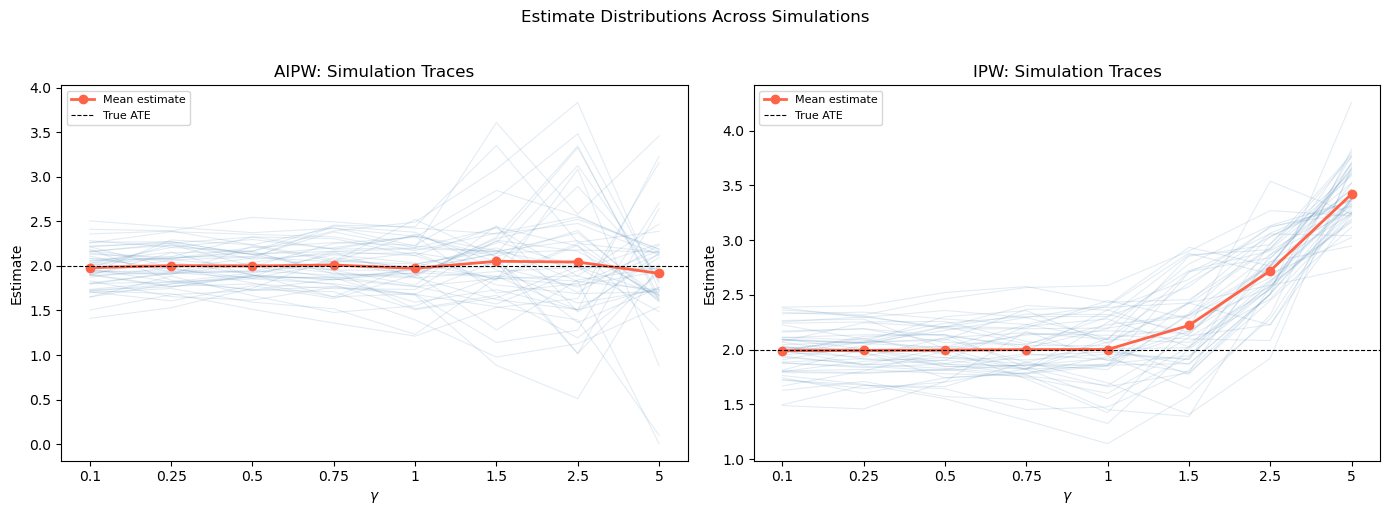

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["AIPW", "IPW"]):
    traces = df[df["estimator"] == name].sort_values("gamma")
    for sim in traces["sim"].unique():
        sim_data = traces[traces["sim"] == sim]
        ax.plot(x_pos, sim_data["estimate"].values,
                color="steelblue", alpha=0.15, linewidth=0.8)
    means = traces.groupby("gamma")["estimate"].mean().values
    ax.plot(x_pos, means, color="tomato", linewidth=2,
            marker="o", label="Mean estimate")
    ax.axhline(TRUE_ATE, color="black", linewidth=0.8,
               linestyle="--", label="True ATE")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Estimate")
    ax.set_title(f"{name}: Simulation Traces")
    ax.legend(fontsize=8)

plt.suptitle("Estimate Distributions Across Simulations", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_sim_traces.png", dpi=150, bbox_inches="tight")
plt.show()

The simulation traces contrast two different failure modes. 

- AIPW keeps its mean
estimate anchored near the true ATE of $2.0$ across all $\gamma$ values, as the
outcome model absorbs the confounding signal and the doubly robust correction
stays honest on average. But the individual traces fan out dramatically above
$\gamma=1.5$, revealing substantial variance inflation driven by the same weight
instability visible in the IPW weight plots. 
- IPW tells a different story: both
the mean and the individual traces drift upward together, reflecting systematic
bias rather than noise. The distinction matters — AIPW is getting the right answer
on average but becoming an unreliable tool for any single dataset, while IPW is
getting the wrong answer consistently.

## Scenario 2: Outcome Nonlinearity

TBC